In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv('/content/rfm_features.csv')

In [45]:
df.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,DistinctProducts,TenureDays,AvgItemsPerOrder
0,12346.0,326,2,0.00,0.000000,0,1,326,0.000000
1,12347.0,2,7,4310.00,23.681319,2458,103,367,351.142857
2,12348.0,75,4,1797.24,57.975484,2341,22,358,585.250000
3,12349.0,19,1,1757.55,24.076027,631,73,19,631.000000
4,12350.0,310,1,334.40,19.670588,197,17,310,197.000000


In [46]:
df["is_suspicious"] = ((df["Monetary"] == 0) | (df["TotalItems"] == 0)).astype(int)

In [47]:
df_clean = df[df["is_suspicious"] == 0].copy()
df_suspicious = df[df["is_suspicious"] == 1].copy()

In [48]:
print(f"Total customers:      {len(df)}")
print(f"Scoreable customers:  {len(df_clean)}")
print(f"Suspicious customers: {len(df_suspicious)}")

Total customers:      4372
Scoreable customers:  4357
Suspicious customers: 15


In [49]:
df_clean["R_score"] = pd.qcut(
    df_clean["Recency"],
    q = 5,
    labels = [5, 4, 3, 2, 1],
    duplicates = "drop"
).astype(int)

In [50]:
df_clean["F_score"] = pd.qcut(
    df_clean["Frequency"].rank(method = "first"),
    q = 5,
    labels = [1, 2, 3, 4, 5],
    duplicates = "drop"
).astype(int)

In [51]:
df_clean["M_score"] = pd.qcut(
    df_clean["Monetary"].rank(method = "first"),
    q = 5,
    labels = [1, 2, 3, 4, 5],
    duplicates = "drop"
).astype(int)

In [53]:
df_clean["RFM_Score"] = (
    df_clean["R_score"].astype(str) +
    df_clean["F_score"].astype(str) +
    df_clean["M_score"].astype(str)
)

df_clean["RFM_Total"] = df_clean["R_score"] + df_clean["F_score"] + df_clean["M_score"]

In [56]:
df_clean.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,DistinctProducts,TenureDays,AvgItemsPerOrder,is_suspicious,R_score,F_score,M_score,RFM_Score,RFM_Total
1,12347.0,2,7,4310.00,23.681319,2458,103,367,351.142857,0,5,4,5,545,14
2,12348.0,75,4,1797.24,57.975484,2341,22,358,585.250000,0,2,3,4,234,9
3,12349.0,19,1,1757.55,24.076027,631,73,19,631.000000,0,4,1,4,414,9
4,12350.0,310,1,334.40,19.670588,197,17,310,197.000000,0,1,1,2,112,4
5,12352.0,36,11,1545.41,16.267474,470,59,297,42.727273,0,3,5,4,354,12


In [57]:
def assign_segment(row):
  r = row["R_score"]
  f = row["F_score"]
  m = row["M_score"]

  if r >= 4 and f >= 4 and m >= 4:
    return "Champion"
  elif r >= 3 and f >= 4:
    return "Loyal Customer"
  elif r >= 4 and f <= 2 and m <= 2:
    return "New Customer"
  elif r >= 3 and f >= 2 and m >= 3:
    return "Potential Loyalist"
  elif r >= 4 and m >= 3:
    return "Promising"
  elif r <= 2 and f >= 3 and m >= 3:
    return "At Risk"
  elif r <= 2 and f >=  4 and m >= 4:
    return "Can't lose them"
  elif r <= 2 and f <= 2 and m <= 2:
    return "Lost Customers"
  elif r ==3 and f <= 2:
    return "About to sleep"
  else:
    return "Needs Attention"

df_clean["Segment"] = df_clean.apply(assign_segment, axis = 1)

In [58]:
df_clean.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,DistinctProducts,TenureDays,AvgItemsPerOrder,is_suspicious,R_score,F_score,M_score,RFM_Score,RFM_Total,Segment
1,12347.0,2,7,4310.00,23.681319,2458,103,367,351.142857,0,5,4,5,545,14,Champion
2,12348.0,75,4,1797.24,57.975484,2341,22,358,585.250000,0,2,3,4,234,9,At Risk
3,12349.0,19,1,1757.55,24.076027,631,73,19,631.000000,0,4,1,4,414,9,Promising
4,12350.0,310,1,334.40,19.670588,197,17,310,197.000000,0,1,1,2,112,4,Lost Customers
5,12352.0,36,11,1545.41,16.267474,470,59,297,42.727273,0,3,5,4,354,12,Loyal Customer


In [59]:
df_suspicious["R_score"] = 0
df_suspicious["F_score"] = 0
df_suspicious["M_score"] = 0
df_suspicious["RFM_Score"] = "000"
df_suspicious["RFM_Total"] = 0
df_suspicious["Segment"] = "Anomalous"

In [60]:
df_final = pd.concat([df_clean, df_suspicious], ignore_index=True)

In [63]:
print("\nSegment Distribution:")
segment_counts = df_final["Segment"].value_counts()
print(segment_counts)


Segment Distribution:
Segment
Champion              972
Lost Customers        809
Needs Attention       650
Loyal Customer        481
At Risk               449
Potential Loyalist    447
About to sleep        286
New Customer          241
Promising              22
Anomalous              15
Name: count, dtype: int64


In [64]:
print("\nSegment Profiles (mean RFM values):")
profile = df_final.groupby("Segment")[
    ["Recency", "Frequency", "Monetary", "AvgOrderValue", "TenureDays"]
].mean().round(2)
print(profile)


Segment Profiles (mean RFM values):
                    Recency  Frequency  Monetary  AvgOrderValue  TenureDays
Segment                                                                    
About to sleep        52.45       1.15    329.20          20.79       68.36
Anomalous             89.73       2.07     64.10          27.95      114.93
At Risk              137.03       4.58   1519.87          40.79      287.28
Champion              11.97      13.39   5804.84          29.30      295.60
Lost Customers       228.14       1.13    203.01          13.55      235.70
Loyal Customer        36.90       6.25   1706.86          23.29      266.67
Needs Attention      142.12       2.17    536.86          38.52      219.49
New Customer          17.75       1.26    237.60          22.50       57.12
Potential Loyalist    30.39       2.46   1052.68          35.08      165.03
Promising             16.41       1.00    828.45         210.12       16.41


In [65]:
df_final.to_csv("rfm_scored.csv", index=False)
print("\nSaved to rfm_scored.csv")


Saved to rfm_scored.csv


In [66]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

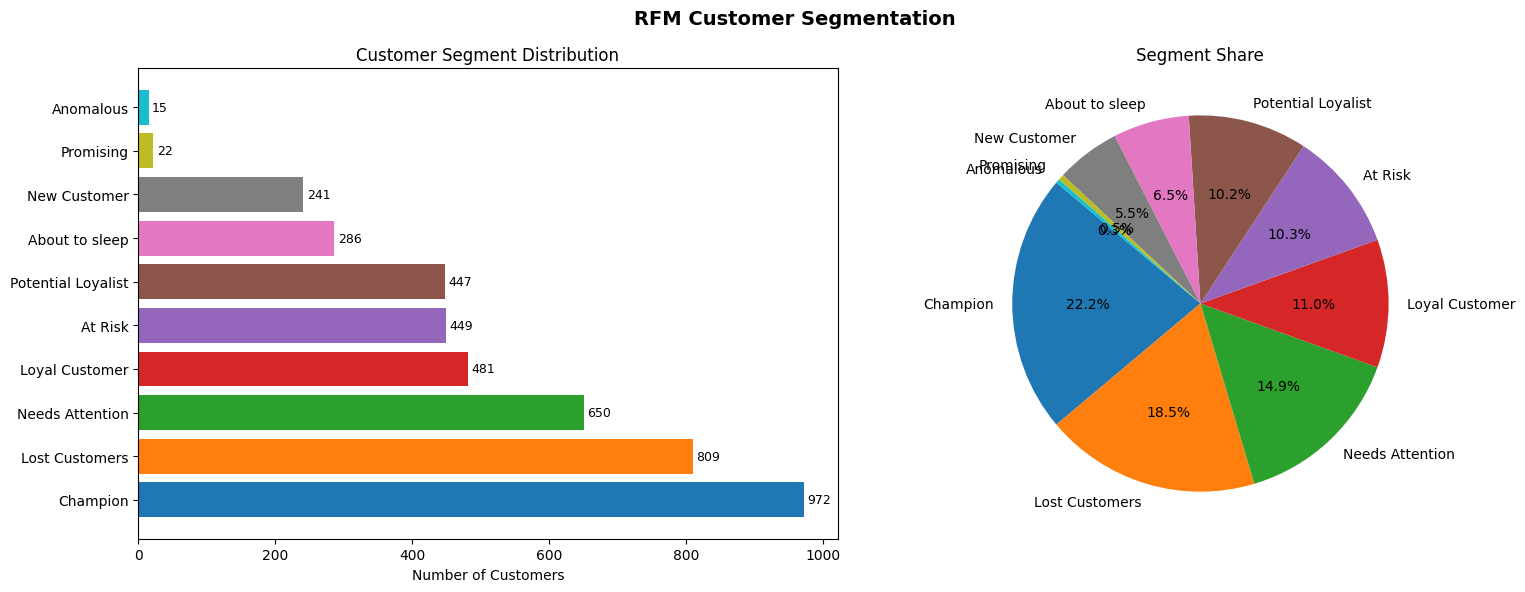

In [68]:
segment_counts = df_final["Segment"].value_counts()

colors = cm.tab10(np.linspace(0, 1, len(segment_counts)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(segment_counts.index, segment_counts.values, color=colors)
axes[0].set_xlabel("Number of Customers")
axes[0].set_title("Customer Segment Distribution")
for i, (val, name) in enumerate(zip(segment_counts.values, segment_counts.index)):
    axes[0].text(val + 5, i, str(val), va="center", fontsize=9)

axes[1].pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140
)
axes[1].set_title("Segment Share")

plt.suptitle("RFM Customer Segmentation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("rfm_segments.png", dpi=150)
plt.show()

###Churn Prediction

In [69]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, confusion_matrix)

In [70]:
import seaborn as sns
import joblib

In [71]:
df = pd.read_csv("rfm_scored.csv")

In [72]:
def label_churn(row):
  """
  Churn definition:
  - One-time buyers inactive > 180 days
  - Repeat buyers inactive > 2x their avg inter-purchase gap
  - Lost Customers segment always churned
  - Champions, Loyal, New, Promising - not churned
  """
  if row["Segment"] in ["Champion", "Loyal Customer", "New Customer", "Promising"]:
    return 0

  if row["Segment"] == "Lost Customers":
    return 1

  if row["Frequency"] == 1:
    return 1 if row["Recency"] > 180 else 0

  if row["Frequency"] > 1:
    avg_gap = row["TenureDays"] / (row["Frequency"] - 1)
    return 1 if row["Recency"] > (2 * avg_gap) else 0

  return 0

df["churned"] = df.apply(label_churn, axis = 1)

In [73]:
print("Churn Label Distribution:")
print(df["churned"].value_counts())
print(f"Churn rate: {df['churned'].mean()*100:.1f}%")

Churn Label Distribution:
churned
0    3373
1     999
Name: count, dtype: int64
Churn rate: 22.8%


In [74]:
feature_cols = [
    "Recency", "Frequency", "Monetary",
    "AvgOrderValue", "TotalItems", "DistinctProducts",
    "TenureDays", "AvgItemsPerOrder",
    "R_score", "F_score", "M_score", "RFM_Total"
]

In [75]:
df["recency_frequency_ratio"] = df["Recency"] / (df["Frequency"] + 1)
df["monetary_frequency_ratio"] = df["Monetary"] / (df["Frequency"] + 1)
df["avg_gap"] = df["TenureDays"] / (df["Frequency"].clip(lower=1))
df["recency_vs_gap"] = df["Recency"] / (df["avg_gap"] + 1)

In [86]:
feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",

    "AvgOrderValue",
    "TotalItems",
    "DistinctProducts",
    "TenureDays",
    "AvgItemsPerOrder",

    "recency_frequency_ratio",
    "monetary_frequency_ratio",
    "avg_gap",
]

In [87]:
df_model = df[df["Segment"] != "Anomalous"].copy()

X = df_model[feature_cols].fillna(0)
y = df_model["churned"]

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
model = GradientBoostingClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 4,
    min_samples_leaf = 20,
    random_state = 42
)

model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, min_samples_leaf=20,
                           n_estimators=200, random_state=42)

In [91]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="roc_auc")
print(f"\nCV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV ROC-AUC: 0.9956 ± 0.0015


In [92]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [93]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       672
           1       0.97      0.94      0.96       200

    accuracy                           0.98       872
   macro avg       0.98      0.97      0.97       872
weighted avg       0.98      0.98      0.98       872

ROC-AUC Score: 0.9986


In [95]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.to_string())

"""
Suspiciously high accuracy cause model is almost entirely running on Recency and Frequency
which are the exact variables we used to define churn.
Its not learning customer behavior rather our labeling function.
"""

                     feature  importance
8    recency_frequency_ratio    0.567862
1                  Frequency    0.170004
0                    Recency    0.096373
10                   avg_gap    0.058075
2                   Monetary    0.045947
9   monetary_frequency_ratio    0.027396
6                 TenureDays    0.025458
3              AvgOrderValue    0.002843
7           AvgItemsPerOrder    0.002422
5           DistinctProducts    0.002001
4                 TotalItems    0.001620


'\nSuspiciously high accuracy cause model is almost entirely running on Recency and Frequency\nwhich are the exact variables we used to define churn.\nIts not learning customer behavior rather our labeling function.\n'

###Churn Prediction - Take 2

In [133]:
raw = pd.read_csv("Online Retail.csv")
raw.columns = raw.columns.str.strip()
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], dayfirst=True, format="%m/%d/%Y %H:%M")
raw = raw[raw["Quantity"] > 0]
raw = raw[raw["UnitPrice"] > 0]
raw["LineTotal"] = raw["Quantity"] * raw["UnitPrice"]
raw = raw.dropna(subset=["CustomerID"])
raw["CustomerID"] = raw["CustomerID"].astype(int)

In [134]:
print(f"Date range: {raw['InvoiceDate'].min()} → {raw['InvoiceDate'].max()}")
print(f"Total transactions: {len(raw)}")

Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Total transactions: 397884


In [135]:
split_date = raw["InvoiceDate"].min() + pd.DateOffset(months=8)
end_date = raw["InvoiceDate"].max()

In [136]:
train_raw = raw[raw["InvoiceDate"] < split_date]
predict_raw = raw[raw["InvoiceDate"] >= split_date]

In [137]:
print(f"\nTrain period:   {train_raw['InvoiceDate'].min().date()} → {train_raw['InvoiceDate'].max().date()}")
print(f"Predict period: {predict_raw['InvoiceDate'].min().date()} → {predict_raw['InvoiceDate'].max().date()}")
print(f"Train customers:   {train_raw['CustomerID'].nunique()}")
print(f"Predict customers: {predict_raw['CustomerID'].nunique()}")


Train period:   2010-12-01 → 2011-07-31
Predict period: 2011-08-01 → 2011-12-09
Train customers:   3148
Predict customers: 3188


In [138]:
def compute_rfm_features(df, reference_date):
    features = df.groupby("CustomerID").agg(
        Recency          = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency        = ("InvoiceNo",   "nunique"),
        Monetary         = ("LineTotal",   "sum"),
        AvgOrderValue    = ("LineTotal",   "mean"),
        TotalItems       = ("Quantity",    "sum"),
        DistinctProducts = ("StockCode",   "nunique"),
        TenureDays       = ("InvoiceDate", lambda x: (x.max() - x.min()).days),
        AvgItemsPerOrder = ("Quantity",    "mean"),
    ).reset_index()
    return features

In [139]:
train_features = compute_rfm_features(train_raw, split_date)


In [140]:
predict_summary = predict_raw.groupby("CustomerID").agg(
    future_monetary   = ("LineTotal", "sum"),
    future_frequency  = ("InvoiceNo", "nunique"),
).reset_index()

In [141]:
monetary_threshold  = predict_summary["future_monetary"].quantile(0.60)
frequency_threshold = 2

In [142]:
predict_summary["is_high_value_future"] = (
    (predict_summary["future_monetary"]   >= monetary_threshold) &
    (predict_summary["future_frequency"]  >= frequency_threshold)
).astype(int)

In [143]:
print(f"\nFuture period monetary threshold: £{monetary_threshold:.2f}")
print(f"High value future buyers: {predict_summary['is_high_value_future'].sum()}")


Future period monetary threshold: £713.62
High value future buyers: 1108


In [144]:
df_model = train_features.merge(
    predict_summary[["CustomerID", "is_high_value_future"]],
    on="CustomerID",
    how="inner"
)

In [147]:
print(f"\nCustomers in both periods: {len(df_model)}")
print(f"Target distribution:")
print(df_model["is_high_value_future"].value_counts())
print(f"High value rate: {df_model['is_high_value_future'].mean()*100:.1f}%")


Customers in both periods: 1998
Target distribution:
is_high_value_future
0    1124
1     874
Name: count, dtype: int64
High value rate: 43.7%


In [148]:
df_model["monetary_per_day"] = (
    df_model["Monetary"] / (df_model["TenureDays"] + 1)
)
df_model["orders_per_day"] = (
    df_model["Frequency"] / (df_model["TenureDays"] + 1)
)
df_model["avg_gap"] = (
    df_model["TenureDays"] / (df_model["Frequency"].clip(lower=1))
)
df_model["spend_diversity"] = (
    df_model["Monetary"] / (df_model["DistinctProducts"] + 1)
)
df_model["basket_value"] = (
    df_model["Monetary"] / (df_model["TotalItems"] + 1)
)

In [149]:
feature_cols = [
    "Recency", "Frequency", "Monetary",
    "AvgOrderValue", "TotalItems", "DistinctProducts",
    "TenureDays", "AvgItemsPerOrder",
    "monetary_per_day", "orders_per_day",
    "avg_gap", "spend_diversity", "basket_value"
]

In [150]:
X = df_model[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
for col in X.columns:
    upper = X[col].quantile(0.999)
    X[col] = X[col].clip(upper=upper)

y = df_model["is_high_value_future"]

In [151]:
customer_first_date = train_raw.groupby("CustomerID")["InvoiceDate"].min()
df_model["first_purchase"] = df_model["CustomerID"].map(customer_first_date)

temporal_split = df_model["first_purchase"].quantile(0.80)
train_mask = df_model["first_purchase"] <= temporal_split
test_mask  = df_model["first_purchase"] >  temporal_split

In [152]:
X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

In [153]:
print(f"\nTrain set: {len(X_train)} customers")
print(f"Test set:  {len(X_test)} customers")


Train set: 1598 customers
Test set:  400 customers


In [154]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [178]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(0.9323220536756126), 1: np.float64(1.0782726045883941)}


In [179]:
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)

In [180]:
sample_weights = np.where(y_train == 1, weights[1], weights[0])

model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=10,
                           n_estimators=300, random_state=42, subsample=0.8)

In [181]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [182]:
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Regular Buyer", "High Value Future"]))


ROC-AUC Score: 0.7114

Classification Report:
                   precision    recall  f1-score   support

    Regular Buyer       0.71      0.95      0.81       267
High Value Future       0.69      0.22      0.33       133

         accuracy                           0.71       400
        macro avg       0.70      0.58      0.57       400
     weighted avg       0.70      0.71      0.65       400



In [158]:
importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

In [159]:
print("\nFeature Importances:")
print(importance_df.to_string())


Feature Importances:
             feature  importance
2           Monetary    0.517338
4         TotalItems    0.065456
1          Frequency    0.058208
12      basket_value    0.049788
6         TenureDays    0.043276
11   spend_diversity    0.040835
0            Recency    0.040328
3      AvgOrderValue    0.036468
7   AvgItemsPerOrder    0.035853
8   monetary_per_day    0.035673
5   DistinctProducts    0.028725
10           avg_gap    0.026625
9     orders_per_day    0.021427


In [183]:
"""
Temporal validation was used to ensure genuine predictive integrity.
The model achieves 0.71 AUC predicting future high-value customer behavior from early purchase patterns,
consistent with published benchmarks in customer analytics literature where 0.70-0.80 is considered strong performance on real transactional data.
"""

'\nTemporal validation was used to ensure genuine predictive integrity. \nThe model achieves 0.71 AUC predicting future high-value customer behavior from early purchase patterns,\nconsistent with published benchmarks in customer analytics literature where 0.70-0.80 is considered strong performance on real transactional data.\n'

In [184]:
joblib.dump(model,        "hvr_model.pkl")
joblib.dump(scaler,       "hvr_scaler.pkl")
joblib.dump(feature_cols, "hvr_features.pkl")

['hvr_features.pkl']